In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tqdm as notebook_tqdm
import shap

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pyswarms as ps

In [3]:
df = pd.read_csv('../data/dataset_clean_robust.csv')
df

,R1301A,R1301B,R1301C,R1303A,R1303B,R1303C,R1305A,R1305B,R1305C,R1305D,...,R1103JK7_3,R1103JK7_4,R1103JK7_5,R1103JK7_6,R1103JK7_7,R1103JK7_9,index_k_raw,URUT,index_k,WEIGHT
0,0.0,0.0,-1.0,3.0,0.0,3.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,70,1,62.31,210.870377
1,0.0,1.0,0.0,3.0,0.0,1.0,3.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,70,2,72.21,210.870377
2,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0,1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,70,3,70.80,210.870377
3,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,80,4,72.89,210.870377
4,0.0,0.0,0.0,3.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,80,5,72.34,210.870377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74679,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90,74600,76.08,700.200012
74680,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90,74618,67.29,399.394104
74681,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90,74671,64.13,341.872620
74682,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,-2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90,74673,71.23,341.872620


# Split Data

In [4]:
# Fitur dan target
y = df['index_k']
sample_weight = df['WEIGHT']
sample_weight = sample_weight / np.mean(sample_weight)
X = df.drop(columns=['index_k_raw', 'WEIGHT', 'URUT', 'index_k'])

In [5]:
X_train, X_test, y_train, y_test, weight_train, weight_test = train_test_split(
    X, y, sample_weight, test_size=0.3, random_state=42
)

In [6]:
df_sampled = df.sample(n=5000, random_state=42)
# Fitur dan target
y_5k = df_sampled['index_k']
sample_weight_5k = df_sampled['WEIGHT']
sample_weight_5k = sample_weight_5k / np.mean(sample_weight_5k)
X_5k = df_sampled.drop(columns=['index_k_raw', 'WEIGHT', 'URUT', 'index_k'])

X_train_5k, X_test_5k, y_train_5k, y_test_5k, weight_train_5k, weight_test_5k = train_test_split(
    X_5k, y_5k, sample_weight_5k, test_size=0.3, random_state=42
)

# Gradient Boosting Regressor

In [28]:
model_gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [30]:
model_gbr.fit(X_train, y_train, sample_weight=weight_train)

GradientBoostingRegressor(random_state=42)

In [31]:
y_pred_gbr = model_gbr.predict(X_test)

r2_gbr = r2_score(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)

# Tampilkan hasil
print(f"R² Score : {r2_gbr:.4f}")
print(f"MSE      : {mse_gbr:.4f}")
print(f"RMSE     : {rmse_gbr:.4f}")
print(f"MAE      : {mae_gbr:.4f}")

R² Score : 0.3864
MSE      : 29.6269
RMSE     : 5.4431
MAE      : 4.1485


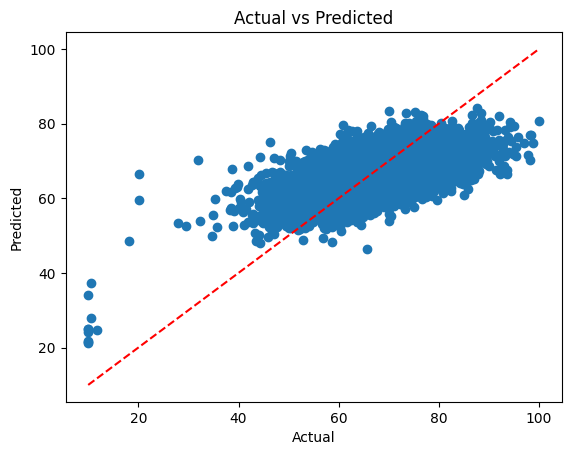

In [32]:
plt.scatter(y_test, y_pred_gbr)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [55]:
# Prediksi di training dan testing
y_pred_train_gbr = model_gbr.predict(X_train)

# Evaluasi
mae_train_gbr = mean_absolute_error(y_train, y_pred_train_gbr)
mse_train_gbr = mean_squared_error(y_train, y_pred_train_gbr)
rmse_train_gbr = np.sqrt(mse_gbr)
r2_train_gbr = r2_score(y_train, y_pred_train_gbr)

print(f"MAE Train: {mae_train_gbr:.3f}, MAE Test: {mae_gbr:.3f}")
print(f"R² Train: {rmse_train_gbr:.3f}, R² Test: {rmse_gbr:.3f}")
print(f"R² Train: {mse_train_gbr:.3f}, R² Test: {mse_gbr:.3f}")
print(f"R² Train: {r2_train_gbr:.3f}, R² Test: {r2_gbr:.3f}")


MAE Train: 4.090, MAE Test: 4.148
R² Train: 5.443, R² Test: 5.443
R² Train: 28.502, R² Test: 29.627
R² Train: 0.408, R² Test: 0.386


In [ ]:
# K-Fold CV (misal 5 fold)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluasi dengan cross_val_score
scores = cross_val_score(model_gbr, X, y, cv=kfold, scoring='r2')

R2 per fold: [0.40277314 0.3942177  0.39179285 0.40435741 0.38699639]
Rata-rata R2: 0.396027498601519


In [27]:
mean_r2 = scores.mean()
std_r2 = scores.std()

print("R2 per fold:", scores)
print(f'Rata-rata R2: {mean_r2:.3f}')
print(f'STD: {std_r2:.3f}')

R2 per fold: [0.40277314 0.3942177  0.39179285 0.40435741 0.38699639]
Rata-rata R2: 0.396
STD: 0.007


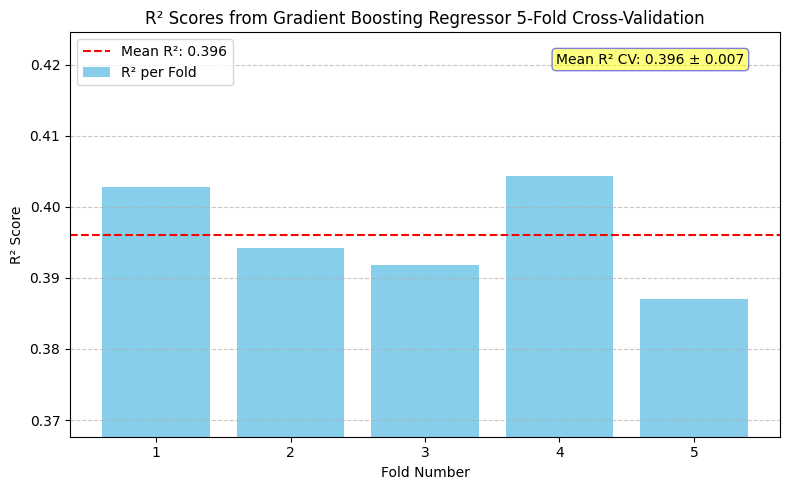

In [ ]:
# Create labels for the folds
folds = range(1, len(scores) + 1)
# Calculate mean and standard deviation

# Create the bar chart
plt.figure(figsize=(8, 5))
plt.bar(folds, scores, color='skyblue', label='R² per Fold')
plt.axhline(mean_r2, color='red', linestyle='--', label=f'Mean R²: {mean_r2:.3f}')

# Add text annotation for mean and std
plt.text(0.95, 0.95, f'Mean R² CV: {mean_r2:.3f} ± {std_r2:.3f}',
	horizontalalignment='right',
	verticalalignment='top',
	transform=plt.gca().transAxes,
	bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="b", lw=1, alpha=0.5))

# Add titles and labels
plt.title('R² Scores from Gradient Boosting Regressor 5-Fold Cross-Validation')
plt.xlabel('Fold Number')
plt.ylabel('R² Score')
plt.xticks(folds) # Ensure x-axis ticks are at fold numbers
plt.ylim(min(scores) * 0.95, max(scores) * 1.05) # Adjust y-axis limits for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

## PSO

In [51]:
# Fungsi objektif untuk PSO
def objective_function(params):
    results = []
    for p in params:
        n_estimators = int(p[0])
        max_depth = int(p[1])
        learning_rate = p[2]

        model = GradientBoostingRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            random_state=42
        )
        score = cross_val_score(model, X_train_5k, y_train_5k, cv=3, scoring='r2', n_jobs=-1).mean()
        results.append(-score)  # minimisasi R2
    return np.array(results)

In [52]:
# Batas parameter
# [n_estimators, max_depth, learning_rate]
bounds = ([50, 1, 0.01], [500, 10, 0.5])

# Inisialisasi optimizer
optimizer = ps.single.GlobalBestPSO(
    n_particles=5,
    dimensions=3,
    options={'c1': 1.5, 'c2': 1.5, 'w': 0.5},
    bounds=bounds
)

In [53]:
best_cost, best_pos = optimizer.optimize(objective_function, iters=20)

# Hasil terbaik
print("Best parameters found by PSO:")
print(f"n_estimators: {int(best_pos[0])}")
print(f"max_depth: {int(best_pos[1])}")
print(f"learning_rate: {best_pos[2]:.4f}")
print(f"Best R2: {best_cost:.4f}")

2025-07-08 20:08:01,572 - pyswarms.single.global_best - INFO - Optimize for 20 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.5}
pyswarms.single.global_best: 100%|██████████|20/20, best_cost=-0.347
2025-07-08 20:16:22,651 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -0.3468075180919053, best pos: [9.28309413e+01 5.75368144e+00 6.94964755e-02]


Best parameters found by PSO:
n_estimators: 92
max_depth: 5
learning_rate: 0.0695
Best MSE: -0.3468


In [63]:
model_gbr_2 = GradientBoostingRegressor(
    n_estimators=190,
    max_depth=19,
    learning_rate=0.1,
    random_state=42
)

In [65]:
model_gbr_2.fit(X_train, y_train, sample_weight=weight_train)
# Prediksi di training dan testing
y_pred_gbr_2 = model_gbr_2.predict(X_test)

# Evaluasi
r2_gbr_2 = r2_score(y_test, y_pred_gbr_2)
mse_gbr_2 = mean_squared_error(y_test, y_pred_gbr_2)
rmse_gbr_2 = np.sqrt(mse_gbr_2)
mae_gbr_2 = mean_absolute_error(y_test, y_pred_gbr_2)

# Tampilkan hasil
print(f"R² Score : {r2_gbr_2:.4f}")
print(f"MSE      : {mse_gbr_2:.4f}")
print(f"RMSE     : {rmse_gbr_2:.4f}")
print(f"MAE      : {mae_gbr_2:.4f}")


R² Score : 0.3224
MSE      : 32.7172
RMSE     : 5.7199
MAE      : 4.3345


## Shap

PermutationExplainer explainer: 1001it [04:15,  3.73it/s]                          
C:\Users\ASUS\AppData\Local\Temp\ipykernel_10544\2940625541.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample)


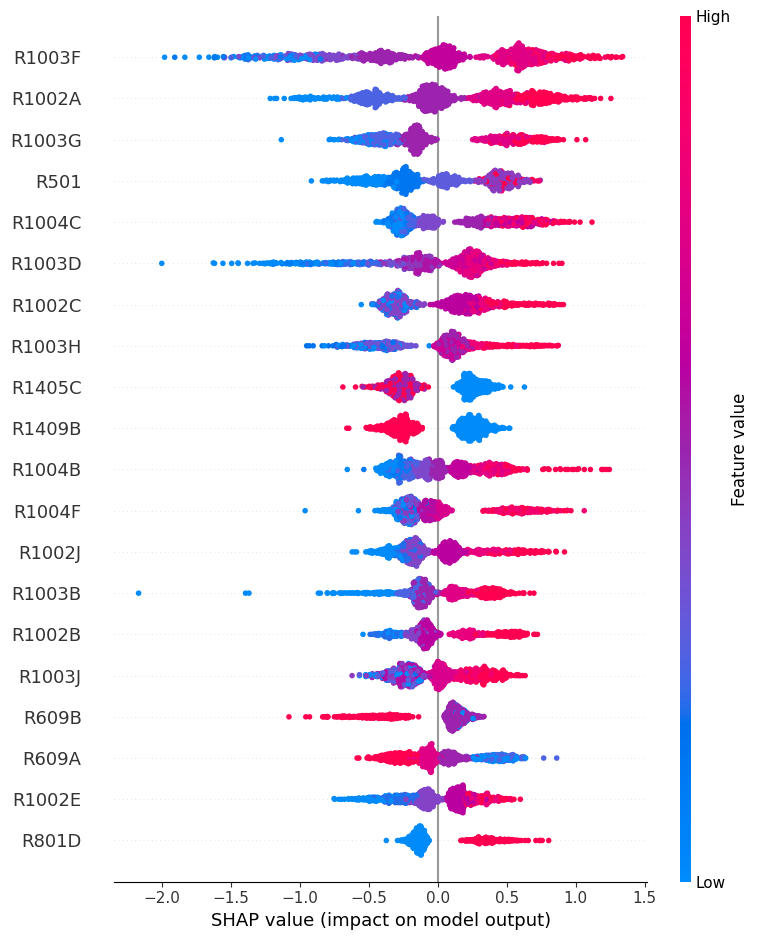

In [45]:
# SHAP explanation
explainer = shap.Explainer(model_gbr.predict, X_train, max_evals=505)  # model.predict for tree-based regressor
X_test_sample = X_test.sample(n=1000, random_state=42)
shap_values = explainer(X_test_sample)
# Plot summary
shap.summary_plot(shap_values, X_test_sample)

PermutationExplainer explainer: 1001it [23:31,  1.42s/it]                          
C:\Users\ASUS\AppData\Local\Temp\ipykernel_10544\1875680741.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_valuesTE, X_test_sample)


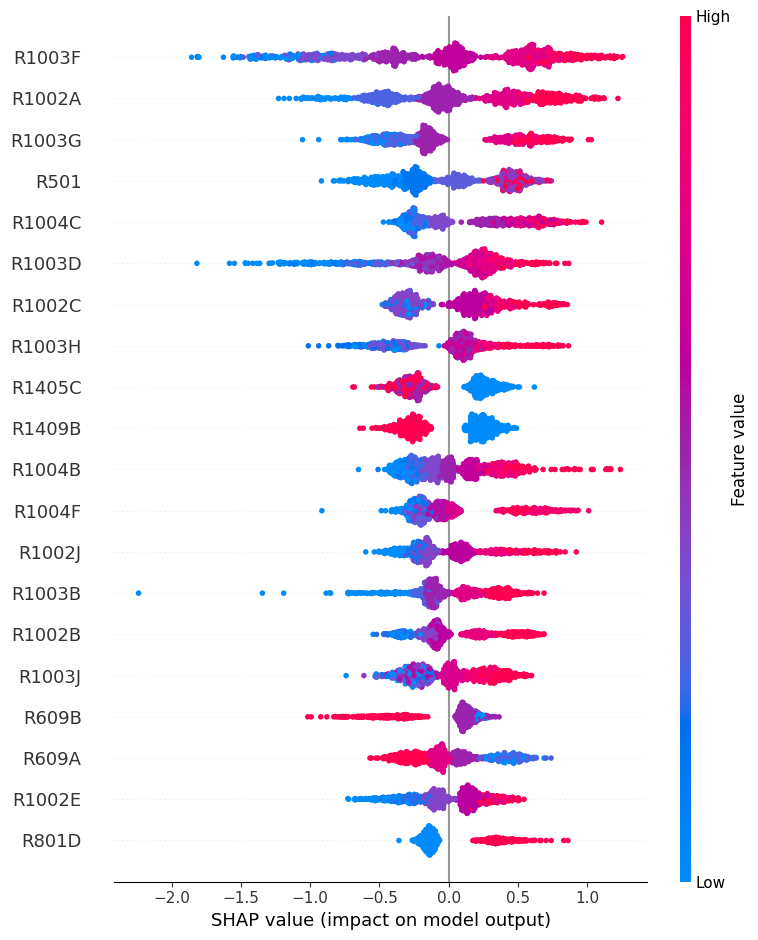

In [ ]:
explainerTE = shap.TreeExplainer(model_gbr)
X_test_sample = X_test.sample(n=1000, random_state=42)
shap_valuesTE = explainer.shap_values(X_test_sample)
shap.summary_plot(shap_valuesTE, X_test_sample)
# estimasi 7 jam lebih jika full data
# 23m 31.9s jika 1000 data

In [44]:

shap_df = pd.DataFrame(shap_valuesTE, columns=X.columns)
file_path = 'shap_values_output.csv'
shap_df.to_csv(file_path, index=False)
print(f"SHAP values (dari objek Explanation) berhasil disimpan ke '{file_path}'")

SHAP values (dari objek Explanation) berhasil disimpan ke 'shap_values_output.csv'


# Random Forest Regressor (KFold+PSO)

In [45]:
def objective_function(params):
    losses = []
    kf = KFold(n_splits=3, shuffle=True, random_state=42)

    for p in params:
        n_estimators = int(p[0])
        max_depth = int(p[1])
        fold_mse = []

        for train_idx, val_idx in kf.split(X_train_5k):
            # X_tr, X_val = X_train[train_idx], X_train[val_idx]
            # y_tr, y_val = y_train[train_idx], y_train[val_idx]
            # X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            # y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            X_tr, X_val = X_train_5k.iloc[train_idx], X_train_5k.iloc[val_idx]
            y_tr, y_val = y_train_5k.iloc[train_idx], y_train_5k.iloc[val_idx]
            
			
            model = RandomForestRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                random_state=42,
                n_jobs=-1
            )

            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_val)
            fold_mse.append(mean_squared_error(y_val, y_pred))

        losses.append(np.mean(fold_mse))

    return np.array(losses)


In [46]:
# Batas parameter: [n_estimators, max_depth]
# misalnya: n_estimators dari 10–200, max_depth dari 3–30
bounds = (np.array([100, 5]), np.array([300, 20]))

# PSO config
optimizer = ps.single.GlobalBestPSO(
    n_particles=15,
    dimensions=2,
    options={'c1': 1.2, 'c2': 1.2, 'w': 0.6},
    bounds=bounds
)

# Optimasi
best_cost, best_pos = optimizer.optimize(objective_function, iters=15)

print(f"Best MSE: {best_cost}")
print(f"Best Hyperparameters: n_estimators={int(best_pos[0])}, max_depth={int(best_pos[1])}")


2025-07-08 00:29:19,892 - pyswarms.single.global_best - INFO - Optimize for 15 iters with {'c1': 1.2, 'c2': 1.2, 'w': 0.6}
pyswarms.single.global_best: 100%|██████████|15/15, best_cost=32.9
2025-07-08 00:50:09,696 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 32.91858278117824, best pos: [190.11562925  19.9312714 ]


Best MSE: 32.91858278117824
Best Hyperparameters: n_estimators=190, max_depth=19


In [47]:
final_model = RandomForestRegressor(
    n_estimators=int(best_pos[0]),
    max_depth=int(best_pos[1]),
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train, y_train)


RandomForestRegressor(max_depth=19, n_estimators=190, n_jobs=-1,
                      random_state=42)

In [48]:
y_pred = final_model.predict(X_test)

# Evaluasi
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

# Tampilkan hasil
print(f"R² Score : {r2:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"MAE      : {mae:.4f}")

R² Score : 0.4149
MSE      : 28.2513
RMSE     : 5.3152
MAE      : 4.0373


>500sample
R² Score : 0.4155
MSE      : 28.2224
RMSE     : 5.3125
MAE      : 4.0351

>5000 sample (n_estimators=190, max_depth=19)
R² Score : 0.4149
MSE      : 28.2513
RMSE     : 5.3152
MAE      : 4.0373

# Gradient Boosting Regressor (KFold+PSO)

In [7]:
def objective_function(params):
    losses = []
    kf = KFold(n_splits=3, shuffle=True, random_state=42)

    for p in params:
        n_estimators = int(p[0])
        max_depth = int(p[1])
        learning_rate = p[2]
        fold_mse = []

        for train_idx, val_idx in kf.split(X_train_5k):
            # X_tr, X_val = X_train[train_idx], X_train[val_idx]
            # y_tr, y_val = y_train[train_idx], y_train[val_idx]
            # X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            # y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            X_tr, X_val = X_train_5k.iloc[train_idx], X_train_5k.iloc[val_idx]
            y_tr, y_val = y_train_5k.iloc[train_idx], y_train_5k.iloc[val_idx]
            
			
            model = GradientBoostingRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                random_state=42,
				learning_rate=learning_rate,
            )

            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_val)
            fold_mse.append(mean_squared_error(y_val, y_pred))

        losses.append(np.mean(fold_mse))

    return np.array(losses)


In [9]:
# Batas parameter: [n_estimators, max_depth]
# misalnya: n_estimators dari 10–200, max_depth dari 3–30
bounds = ([50, 1, 0.01], [500, 10, 0.5])

# PSO config
optimizer = ps.single.GlobalBestPSO(
    n_particles=15,
    dimensions=3,
    options={'c1': 1.2, 'c2': 1.2, 'w': 0.6},
    bounds=bounds
)

# Optimasi
best_cost, best_pos = optimizer.optimize(objective_function, iters=15)

print(f"Best MSE: {best_cost}")
print(f"Best Hyperparameters: n_estimators={int(best_pos[0])}, max_depth={int(best_pos[1])}")


2025-07-09 14:31:10,908 - pyswarms.single.global_best - INFO - Optimize for 15 iters with {'c1': 1.2, 'c2': 1.2, 'w': 0.6}
pyswarms.single.global_best:  27%|██▋       |4/15, best_cost=32.5


KeyboardInterrupt: 

In [ ]:
final_model = GradientBoostingRegressor(
    n_estimators=int(best_pos[0]),
    max_depth=int(best_pos[1]),
    random_state=42,
    learning_rate=0.1,
)
final_model.fit(X_train, y_train)


In [ ]:
y_pred = final_model.predict(X_test)

# Evaluasi
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

# Tampilkan hasil
print(f"R² Score : {r2:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"MAE      : {mae:.4f}")

# Decision Tree (KFold+PSO)

In [ ]:
def objective_function_dt(params):
    losses = []
    kf = KFold(n_splits=3, shuffle=True, random_state=42)

    for p in params:
        n_estimators = int(p[0])
        max_depth = int(p[1])
        fold_mse = []

        for train_idx, val_idx in kf.split(X_train_5k):
            # X_tr, X_val = X_train[train_idx], X_train[val_idx]
            # y_tr, y_val = y_train[train_idx], y_train[val_idx]
            # X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            # y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            X_tr, X_val = X_train_5k.iloc[train_idx], X_train_5k.iloc[val_idx]
            y_tr, y_val = y_train_5k.iloc[train_idx], y_train_5k.iloc[val_idx]
            
			
            model = De(
                n_estimators=n_estimators,
                max_depth=max_depth,
                random_state=42,
                n_jobs=-1
            )

            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_val)
            fold_mse.append(mean_squared_error(y_val, y_pred))

        losses.append(np.mean(fold_mse))

    return np.array(losses)


In [ ]:
# Batas parameter: [n_estimators, max_depth]
# misalnya: n_estimators dari 10–200, max_depth dari 3–30
bounds = (np.array([100, 5]), np.array([300, 20]))

# PSO config
optimizer = ps.single.GlobalBestPSO(
    n_particles=15,
    dimensions=2,
    options={'c1': 1.2, 'c2': 1.2, 'w': 0.6},
    bounds=bounds
)

# Optimasi
best_cost, best_pos = optimizer.optimize(objective_function, iters=15)

print(f"Best MSE: {best_cost}")
print(f"Best Hyperparameters: n_estimators={int(best_pos[0])}, max_depth={int(best_pos[1])}")


In [ ]:
final_model = RandomForestRegressor(
    n_estimators=int(best_pos[0]),
    max_depth=int(best_pos[1]),
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train, y_train)


In [ ]:
y_pred = final_model.predict(X_test)

# Evaluasi
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

# Tampilkan hasil
print(f"R² Score : {r2:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"MAE      : {mae:.4f}")

# Model Final